# Race pace predictor


## Phase 1.1 — Downloading Garmin Data


> First launch: enter email + password once, then token is saved.

### 1. Library Imports and Configuration

In [1]:
import os
import json
import time
import logging
import getpass
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timezone
from dotenv import load_dotenv
from garminconnect import Garmin

load_dotenv("garmin_config.env")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)s  %(message)s",
    datefmt="%H:%M:%S"
)
log = logging.getLogger(__name__)

# Paths
DATA_DIR        = Path("data/raw")
DETAILS_DIR     = DATA_DIR / "details"
ACTIVITIES_FILE = DATA_DIR / "activities.json"
SYNC_FILE       = Path("data/last_sync.json")
TOKEN_DIR       = Path("data/garth_tokens")

for d in [DATA_DIR, DETAILS_DIR, TOKEN_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Activity types to EXCLUDE
EXCLUDED_TYPES = {
    "diving",
    "scuba_diving",
    "apnea_diving",
    "apnea_hunting",
    "single_gas_diving",
    "multi_gas_diving",
    "gauge_diving",
}

REQUEST_DELAY = 0.8  # secondes entre requetes

print("Configuration loaded")

Configuration loaded


/Users/guillaumewagli/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### 2. Connecting to Garmin Connect
Uses the cached session token — avoids 429 errors. Email/password only required on first launch.

In [2]:
def connect_to_garmin():
    token_path = str(TOKEN_DIR)

    if TOKEN_DIR.exists() and any(TOKEN_DIR.iterdir()):
        try:
            c = Garmin()
            c.login(token_path)
            log.info("Connected via session token (no SSO request)")
            return c
        except Exception as e:
            log.warning("Token invalid or expired (%s), reconnecting...", e)

    email    = os.getenv("GARMIN_EMAIL")    or input("Garmin Email: ").strip()
    password = os.getenv("GARMIN_PASSWORD") or getpass.getpass("Garmin Password: ")

    c = Garmin(email, password)
    c.login()
    c.garth.dump(token_path)
    log.info("Connected and token saved in %s", TOKEN_DIR)
    return c


client = connect_to_garmin()

13:56:38  INFO  Connected via session token (no SSO request)


### 3. Utility Functions

In [3]:
def load_json(path, default):
    """Load a JSON file. If corrupted, saves .bak and returns default."""
    if path.exists():
        try:
            with open(path, encoding="utf-8") as f:
                return json.load(f)
        except json.JSONDecodeError:
            bak = path.with_suffix(".json.bak")
            path.rename(bak)
            log.warning("Corrupted JSON: %s -> backup: %s", path, bak)
    return default


def save_json(path, data):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)


def get_last_sync():
    data = load_json(SYNC_FILE, {})
    if "last_sync" in data:
        return datetime.fromisoformat(data["last_sync"])
    return None


def save_last_sync():
    now = datetime.now(timezone.utc).isoformat()
    save_json(SYNC_FILE, {"last_sync": now})
    log.info("Sync date saved: %s", now)


def is_excluded(activity):
    """True if the activity should be ignored (diving and variants)."""
    type_key = (
        activity.get("activityType", {})
                .get("typeKey", "")
                .lower()
    )
    return type_key in EXCLUDED_TYPES


print("Utility functions defined")

Utility functions defined


### 4. Downloading Metadata via `get_activities()`

`get_activities()` returns complete metadata for each activity:
distance, durée, FC moyenne, pace, dénivelé, VO2max, effets d'entraînement...

This is the only endpoint needed to build the model.

- **First sync**: downloads the full history in pages of 100.
- **Subsequent syncs**: fetches only activities after the last sync.

In [4]:
def fetch_activities_metadata(client, last_sync):
    """
    Download activity metadata from get_activities().
    Retourne uniquement les activites non exclues.
    """
    all_activities = []
    batch_size     = 100
    start_index    = 0
    is_first_sync  = last_sync is None

    if is_first_sync:
        log.info("First sync: downloading full history")
    else:
        log.info("Incremental sync from %s", last_sync.date())

    while True:
        log.info("  Page %d -> %d ...", start_index, start_index + batch_size)
        batch = client.get_activities(start_index, batch_size)

        if not batch:
            break

        stop          = False
        kept_in_batch = []

        for act in batch:
            # Sync incremental : stop once we reach already known activities
            if not is_first_sync:
                start_str = act.get("startTimeLocal", "")
                if start_str:
                    act_date = datetime.fromisoformat(start_str).replace(tzinfo=timezone.utc)
                    if act_date <= last_sync:
                        stop = True
                        break

            # Exclusion diving
            if is_excluded(act):
                log.info("    Skip: %s (#%s)",
                         act.get("activityType", {}).get("typeKey", "?"),
                         act.get("activityId"))
                continue

            kept_in_batch.append(act)

        all_activities.extend(kept_in_batch)

        if stop or len(batch) < batch_size:
            break

        start_index += batch_size
        time.sleep(REQUEST_DELAY)

    log.info("%d activity(ies) retrieved", len(all_activities))
    return all_activities


def update_activities_index(new_data):
    """Merge new activities with the existing index, without duplicates."""
    existing     = load_json(ACTIVITIES_FILE, [])
    existing_ids = {a["activityId"] for a in existing}
    truly_new    = [a for a in new_data if a["activityId"] not in existing_ids]

    merged = truly_new + existing
    merged.sort(key=lambda a: a.get("startTimeLocal", ""), reverse=True)

    save_json(ACTIVITIES_FILE, merged)
    log.info("Index: +%d new, %d total", len(truly_new), len(merged))
    return merged


# Execution
last_sync      = get_last_sync()
new_activities = fetch_activities_metadata(client, last_sync)
all_activities = update_activities_index(new_activities)
save_last_sync()

print("Sync complete: {} activity(ies) in index".format(len(all_activities)))

13:56:38  INFO  Incremental sync from 2026-06-13
13:56:38  INFO    Page 0 -> 100 ...
13:56:38  INFO  0 activity(ies) retrieved
13:56:39  INFO  Index: +0 new, 448 total
13:56:39  INFO  Sync date saved: 2026-06-13T11:56:39.057300+00:00


Sync complete: 448 activity(ies) in index


### 5. Data Preview and Diagnostics


In [5]:
all_activities = load_json(ACTIVITIES_FILE, [])

if not all_activities:
    print("WARNING: no activity found in", ACTIVITIES_FILE)
else:
    rows = []
    for act in all_activities:
        avg_speed = act.get("averageSpeed")  # m/s
        rows.append({
            "id"          : act.get("activityId"),
            "date"        : act.get("startTimeLocal", "")[:10],
            "type"        : act.get("activityType", {}).get("typeKey", ""),
            "name"         : act.get("activityName", ""),
            "distance_km" : round(act.get("distance", 0) / 1000, 2),
            "duration_min"   : round(act.get("duration", 0) / 60, 1),
            "duration_s"     : act.get("duration"),
            "elevation_m"  : act.get("elevationGain", 0),
            "avg_hr"      : act.get("averageHR"),
            "max_hr"      : act.get("maxHR"),
            "pace_s_km" : round(1000 / avg_speed, 1) if avg_speed and avg_speed > 0 else None,
            "cadence"     : act.get("averageRunningCadenceInStepsPerMinute"),
            "VO2max"      : act.get("vO2MaxValue"),
            "aerobic_effect"  : act.get("aerobicTrainingEffect"),
            "anaerobic_effect": act.get("anaerobicTrainingEffect"),
            "calories"    : act.get("calories"),
        })

    df = pd.DataFrame(rows)

    print("=" * 60)
    print("VUE GENERALE")
    print("=" * 60)
    print("Activities: {}".format(len(df)))
    print("Period   : {} -> {}".format(df["date"].min(), df["date"].max()))

    print("\n" + "=" * 60)
    print("REPARTITION PAR TYPE")
    print("=" * 60)
    print(df["type"].value_counts().to_string())

    print("\n" + "=" * 60)
    print("VALEURS MANQUANTES (% par colonne)")
    print("=" * 60)
    missing = (df.isnull().sum() / len(df) * 100).round(1)
    missing = missing[missing > 0].sort_values(ascending=False)
    print(missing.to_string() if len(missing) > 0 else "Aucune valeur manquante")

    print("\n" + "=" * 60)
    print("STATISTIQUES DESCRIPTIVES")
    print("=" * 60)
    print(df.describe().round(2).to_string())

    print("\n" + "=" * 60)
    print("APERCU 20 PREMIERES LIGNES")
    print("=" * 60)
    print(df.head(20).to_string())

VUE GENERALE
Activities: 448
Period   : 2022-12-03 -> 2026-06-12

REPARTITION PAR TYPE
type
running                220
backcountry_skiing      48
trail_running           45
cycling                 39
lap_swimming            20
road_biking             17
indoor_cycling          17
mountain_biking         15
gravel_cycling          12
other                    4
hiking                   3
open_water_swimming      3
multi_sport              2
resort_skiing            1
kayaking_v2              1
skate_skiing_ws          1

VALEURS MANQUANTES (% par colonne)
VO2max       43.8
cadence      39.5
pace_s_km     4.0
avg_hr        3.6
max_hr        3.3

STATISTIQUES DESCRIPTIVES
                 id  distance_km  duration_min  duration_s  elevation_m  avg_hr  max_hr  pace_s_km  cadence  VO2max  aerobic_effect  anaerobic_effect  calories
count  4.480000e+02       448.00        448.00      448.00       448.00  432.00  433.00     430.00   271.00  252.00          448.00            448.00    448.00
mea

## Phase 1.2 — Cleaning & Feature Engineering

**Strategy:**
- All activities are used to compute the **training load**
- Only `running` and `trail_running` form the **modelling dataset**

**Output files:**
```
data/
  processed/
    all_activities_clean.csv    <- all cleaned activities (for load)
    running_dataset.csv         <- final dataset ready for modelling

### 1. Imports and Data Loading

In [6]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

# Paths
DATA_DIR        = Path("data/raw")
PROCESSED_DIR   = Path("data/processed")
ACTIVITIES_FILE = DATA_DIR / "activities.json"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

# Loading
with open(ACTIVITIES_FILE, encoding="utf-8") as f:
    raw = json.load(f)

print("Activities loaded: {}".format(len(raw)))

Activities loaded: 448


### 2. Building the Raw DataFrame (all activities)

In [7]:
rows = []
for act in raw:
    avg_speed = act.get("averageSpeed")  # m/s
    avg_hr    = act.get("averageHR")
    duration_min = act.get("duration", 0) / 60

    rows.append({
        "id"               : act.get("activityId"),
        "date"             : pd.to_datetime(act.get("startTimeLocal", "")[:19]),
        "type"             : act.get("activityType", {}).get("typeKey", ""),
        "name"              : act.get("activityName", ""),
        "distance_km"      : act.get("distance", 0) / 1000,
        "duration_s"          : act.get("duration", 0),
        "duration_min"        : duration_min,
        "elevation_m"       : act.get("elevationGain", 0) or 0,
        "avg_hr"           : avg_hr,
        "max_hr"           : act.get("maxHR"),
        "pace_s_km"      : round(1000 / avg_speed, 1) if avg_speed and avg_speed > 0 else None,
        "cadence"          : act.get("averageRunningCadenceInStepsPerMinute"),
        "VO2max"           : act.get("vO2MaxValue"),
        "aerobic_effect"       : act.get("aerobicTrainingEffect") or 0,
        "anaerobic_effect"     : act.get("anaerobicTrainingEffect") or 0,
        "calories"         : act.get("calories") or 0,
        # Nouvelles features brutes
        "avg_power"        : act.get("avgPower"),
        "norm_power"       : act.get("normPower"),
        "training_load"    : act.get("activityTrainingLoad"),
        "grade_adj_speed"  : act.get("avgGradeAdjustedSpeed"),
        "stride_length"    : act.get("avgStrideLength"),
        "water_estimated"  : act.get("waterEstimated"),
        "hr_zone1"         : act.get("hrTimeInZone_1"),
        "hr_zone2"         : act.get("hrTimeInZone_2"),
        "hr_zone3"         : act.get("hrTimeInZone_3"),
        "hr_zone4"         : act.get("hrTimeInZone_4"),
        "hr_zone5"         : act.get("hrTimeInZone_5"),
        "fastest_1km"      : act.get("fastestSplit_1000"),
        "fastest_5km"      : act.get("fastestSplit_5000"),
        "fastest_10km"     : act.get("fastestSplit_10000"),
    })

df_all = pd.DataFrame(rows)
df_all = df_all.sort_values("date").reset_index(drop=True)

print("Shape : {}".format(df_all.shape))
print("Periode : {} -> {}".format(df_all["date"].min().date(), df_all["date"].max().date()))
print("\nTypes :")
print(df_all["type"].value_counts().to_string())
print("\nDisponibilite des nouvelles features (% non-null) :")
new_cols = ["avg_power", "norm_power", "training_load", "grade_adj_speed",
            "stride_length", "water_estimated", "fastest_1km", "fastest_5km", "fastest_10km"]
for col in new_cols:
    pct = df_all[col].notna().mean() * 100
    print("  {:25s} : {:.0f}%".format(col, pct))

Shape : (448, 30)
Periode : 2022-12-03 -> 2026-06-12

Types :
type
running                220
backcountry_skiing      48
trail_running           45
cycling                 39
lap_swimming            20
indoor_cycling          17
road_biking             17
mountain_biking         15
gravel_cycling          12
other                    4
open_water_swimming      3
hiking                   3
multi_sport              2
skate_skiing_ws          1
kayaking_v2              1
resort_skiing            1

Disponibilite des nouvelles features (% non-null) :
  avg_power                 : 55%
  norm_power                : 55%
  training_load             : 100%
  grade_adj_speed           : 70%
  stride_length             : 60%
  water_estimated           : 65%
  fastest_1km               : 43%
  fastest_5km               : 41%
  fastest_10km              : 16%


### 3. Cleaning — all activities
All activities are kept for training load, but outliers are filtered out.

In [8]:
n0 = len(df_all)

# Remove accidental activities (< 1 min or < 100m)
df_all = df_all[(df_all["duration_min"] >= 1) & (df_all["distance_km"] >= 0.1)].copy()
print("After duration/distance filter: {} (removed {})".format(len(df_all), n0 - len(df_all)))

# Missing HR imputation — median computed on training data only
SPLIT = pd.Timestamp("2026-01-01")
mask_train_all = df_all["date"] < SPLIT

hr_median_train = df_all[mask_train_all].groupby("type")["avg_hr"].median()
hr_global_train  = df_all.loc[mask_train_all, "avg_hr"].median()

def impute_fc(row):
    if pd.isna(row["avg_hr"]):
        return hr_median_train.get(row["type"], hr_global_train)
    return row["avg_hr"]

df_all["avg_hr"] = df_all.apply(impute_fc, axis=1)

print("avg_hr manquantes restantes : {}".format(df_all["avg_hr"].isnull().sum()))
print("Activities kept: {}".format(len(df_all)))

After duration/distance filter: 429 (removed 19)
avg_hr manquantes restantes : 2
Activities kept: 429


### 4. Computing TRIMP and Training Load Features

**TRIMP** (Training IMPulse) quantifies the load of each session, across all activity types:

```
TRIMP = duration_min x avg_hr x 0.64 x e^(1.92 x avg_hr_norm)
```

où `avg_hr_norm = (avg_hr - resting_hr) / (max_hr_theorique - resting_hr)`

Then for each activity, load features are computed using **rolling windows**:
- `ATL` (Acute Training Load): 7-day TRIMP average = acute fatigue
- `CTL` (Chronic Training Load): 42-day TRIMP average = chronic fitness
- `TSB` (Training Stress Balance): CTL - ATL = freshness

In [9]:
# Physiological parameters (adjustable)
FC_REPOS       = 45   # resting bpm
MAX_HR_THEORY = 185  # theoretical max bpm

def compute_trimp(duration_min, avg_hr, resting_hr=FC_REPOS, max_hr=MAX_HR_THEORY):
    """Compute the TRIMP of a session."""
    if pd.isna(avg_hr) or duration_min <= 0:
        return 0.0
    hr_norm = (avg_hr - resting_hr) / max(max_hr - resting_hr, 1)
    hr_norm = max(0, min(hr_norm, 1))  # clip entre 0 et 1
    return duration_min * hr_norm * 0.64 * np.exp(1.92 * hr_norm)


# Compute TRIMP for each activity
df_all["trimp"] = df_all.apply(
    lambda r: compute_trimp(r["duration_min"], r["avg_hr"]), axis=1
)

# Reindex by date for rolling windows
df_trimp = df_all[["date", "trimp"]].copy()
df_trimp = df_trimp.set_index("date").sort_index()

# Daily series (sum TRIMP per day)
trimp_daily = df_trimp["trimp"].resample("D").sum()

# ATL (7d), CTL (42d), TSB
atl = trimp_daily.rolling(7,  min_periods=1).mean()
ctl = trimp_daily.rolling(42, min_periods=1).mean()
tsb = ctl - atl

# Cumulative load 7d and 28d
load_7d  = trimp_daily.rolling(7,  min_periods=1).sum()
load_28d = trimp_daily.rolling(28, min_periods=1).sum()

# Attach to each activity (J-1 value to avoid data leakage)
def get_charge_at(date, series):
    """Returns the series value on the day preceding the given date."""
    prev = series[series.index < date]
    return float(prev.iloc[-1]) if len(prev) > 0 else 0.0


df_all["ATL"]     = df_all["date"].apply(lambda d: get_charge_at(d, atl))
df_all["CTL"]     = df_all["date"].apply(lambda d: get_charge_at(d, ctl))
df_all["TSB"]     = df_all["date"].apply(lambda d: get_charge_at(d, tsb))
df_all["load_7d"] = df_all["date"].apply(lambda d: get_charge_at(d, load_7d))
df_all["load_28d"]= df_all["date"].apply(lambda d: get_charge_at(d, load_28d))

# Days since last activity
df_all["rest_days"] = df_all["date"].diff().dt.days.fillna(0)

print("Training load features computed")
print(df_all[["date", "type", "trimp", "ATL", "CTL", "TSB", "load_7d", "rest_days"]].tail(10).to_string())

Training load features computed
                   date           type       trimp         ATL        CTL        TSB      load_7d  rest_days
438 2026-06-01 11:52:33        running   59.652608   81.541614  70.167657 -11.373958   570.791300        2.0
439 2026-06-02 19:20:25        running  116.977827   80.330856  71.075023  -9.255833   562.315991        1.0
440 2026-06-04 12:15:07        running   69.815252   84.720113  70.973602 -13.746511   593.040791        1.0
441 2026-06-05 09:31:55        cycling  570.530269  139.089800  84.557656 -54.532145   973.628602        0.0
442 2026-06-06 09:15:04        cycling  180.615892  142.513121  88.858034 -53.655087   997.591848        0.0
443 2026-06-07 10:45:02         hiking   77.477293  153.581306  90.702732 -62.878574  1075.069141        1.0
444 2026-06-09 18:08:53  trail_running  316.228929  173.523948  95.459381 -78.064566  1214.667635        2.0
445 2026-06-10 18:57:24        running   76.878633  184.506610  97.289825 -87.216785  1291.54626

### 5. Saving the Full Dataset (all activities)

In [10]:
out_all = PROCESSED_DIR / "all_activities_clean.csv"
df_all.to_csv(out_all, index=False)
print("Saved: {} ({} rows)".format(out_all, len(df_all)))

Saved: data/processed/all_activities_clean.csv (429 rows)


### 6. Building the Modelling Dataset (running + trail only)

In [11]:
RUNNING_TYPES = {"running", "trail_running"}

df_run = df_all[df_all["type"].isin(RUNNING_TYPES)].copy()
print("Runs before cleaning: {}".format(len(df_run)))

n = len(df_run)

# Filtres
df_run = df_run[(df_run["distance_km"] >= 1) & (df_run["distance_km"] <= 100)]
print("After distance filter (1-100 km): {} (removed {})".format(len(df_run), n - len(df_run)))
n = len(df_run)

df_run = df_run[(df_run["duration_min"] >= 5) & (df_run["duration_min"] <= 720)]
print("After duration filter (5-720 min): {} (removed {})".format(len(df_run), n - len(df_run)))
n = len(df_run)

df_run = df_run[
    df_run["pace_s_km"].isna() |
    ((df_run["pace_s_km"] >= 200) & (df_run["pace_s_km"] <= 1200))
]
print("After pace filter (200-1200 s/km): {} (removed {})".format(len(df_run), n - len(df_run)))
n = len(df_run)

# ── Base features ────────────────────────────────────────────────────────────
df_run["eq_distance_km"]  = df_run["distance_km"] + df_run["elevation_m"] / 100
df_run["eq_pace_s_km"]  = df_run["duration_s"] / df_run["eq_distance_km"]
df_run["is_trail"]        = (df_run["type"] == "trail_running").astype(int)
df_run["elevation_per_km"] = df_run["elevation_m"] / df_run["distance_km"]
df_run["month"]            = df_run["date"].dt.month

# ── Race fatigue features ────────────────────────────────────────────────────
RIEGEL_B = 1.06
df_run["riegel_factor"]    = df_run["distance_km"] ** RIEGEL_B
df_run["difficulty_index"]= df_run["eq_distance_km"] ** RIEGEL_B
df_run["log_eq_distance"]  = np.log(df_run["eq_distance_km"])
df_run["relative_elevation"] = df_run["elevation_m"] / df_run["distance_km"]

# ── Nouvelles features derivees ───────────────────────────────────────────────
# % du temps dans chaHR zone (normalized by duration)
for z in [1, 2, 3, 4, 5]:
    col = "hr_zone{}".format(z)
    df_run["pct_zone{}".format(z)] = (df_run[col] / df_run["duration_s"]).fillna(0)

# Vitesse ajustee du elevation (Garmin) -> pace equivalente en s/km
df_run["grade_adj_pace_s_km"] = df_run["grade_adj_speed"].apply(
    lambda v: round(1000 / v, 1) if v and v > 0 else None
)

# Puissance normalisee disponible (pas de power across all runs)
# On garde avg_power et norm_power tels quels, imputation plus tard

print("Features calculees")

# ── Imputation ───────────────────────────────────────────────────────────────
mask_train_run = df_run["date"] < SPLIT

cadence_med = df_run.loc[mask_train_run, "cadence"].median()
df_run["cadence"] = df_run["cadence"].fillna(cadence_med)

df_run["VO2max"] = df_run["VO2max"].replace(60.0, np.nan)
vo2max_med = df_run.loc[mask_train_run, "VO2max"].median()
df_run["VO2max"] = df_run["VO2max"].fillna(vo2max_med)

# Imputation puissance par mediane train
for col in ["avg_power", "norm_power", "training_load", "stride_length",
            "grade_adj_pace_s_km"]:
    med = df_run.loc[mask_train_run, col].median()
    df_run[col] = df_run[col].fillna(med)

# fastest splits : disponibles uniquement sur some distances -> median imputation
for col in ["fastest_1km", "fastest_5km", "fastest_10km"]:
    med = df_run.loc[mask_train_run, col].median()
    df_run[col] = df_run[col].fillna(med)

df_run = df_run.reset_index(drop=True)
print("\nFinal dataset: {} runs".format(len(df_run)))
print("Running: {}  |  Trail: {}".format(
    (df_run["type"] == "running").sum(),
    (df_run["type"] == "trail_running").sum()
))
print("\nDisponibilite features nouvelles :")
for col in ["avg_power", "norm_power", "training_load", "grade_adj_pace_s_km",
            "stride_length", "fastest_1km", "pct_zone3", "pct_zone4"]:
    pct_null = df_run[col].isnull().mean() * 100
    print("  {:30s} manquant: {:.1f}%".format(col, pct_null))

Runs before cleaning: 265
After distance filter (1-100 km): 265 (removed 0)
After duration filter (5-720 min): 265 (removed 0)
After pace filter (200-1200 s/km): 265 (removed 0)
Features calculees

Final dataset: 265 runs
Running: 220  |  Trail: 45

Disponibilite features nouvelles :
  avg_power                      manquant: 0.0%
  norm_power                     manquant: 0.0%
  training_load                  manquant: 0.0%
  grade_adj_pace_s_km            manquant: 0.0%
  stride_length                  manquant: 0.0%
  fastest_1km                    manquant: 0.0%
  pct_zone3                      manquant: 0.0%
  pct_zone4                      manquant: 0.0%


### 7. Saving the Modelling Dataset

In [12]:
# Final columns for modelling
FEATURES = [
    "id", "date", "type", "name",
    # Target variable
    "duration_s",
    # Base features
    "distance_km", "eq_distance_km", "elevation_m", "elevation_per_km",
    "pace_s_km", "eq_pace_s_km",
    "avg_hr", "max_hr", "cadence", "VO2max",
    "aerobic_effect", "anaerobic_effect", "calories",
    "is_trail", "month",
    # Race fatigue features
    "riegel_factor", "difficulty_index", "log_eq_distance", "relative_elevation",
    # Nouvelles features physiologiques
    "avg_power", "norm_power", "training_load",
    "grade_adj_pace_s_km", "stride_length",
    "pct_zone1", "pct_zone2", "pct_zone3", "pct_zone4", "pct_zone5",
    "fastest_1km", "fastest_5km", "fastest_10km",
    # Training load features (all activities)
    "trimp", "ATL", "CTL", "TSB", "load_7d", "load_28d", "rest_days",
]

df_final = df_run[FEATURES].copy()

out_run = PROCESSED_DIR / "running_dataset.csv"
df_final.to_csv(out_run, index=False)
print("Saved: {} ({} rows, {} columns)".format(out_run, len(df_final), len(df_final.columns)))

missing = (df_final.isnull().sum() / len(df_final) * 100).round(1)
missing = missing[missing > 0]
if len(missing) > 0:
    print("\nRemaining missing values:")
    print(missing.to_string())
else:
    print("\nNo missing values in final dataset")

Saved: data/processed/running_dataset.csv (265 rows, 44 columns)

No missing values in final dataset


### 1.3 EDA

#### 1 Distribution of Key Variables

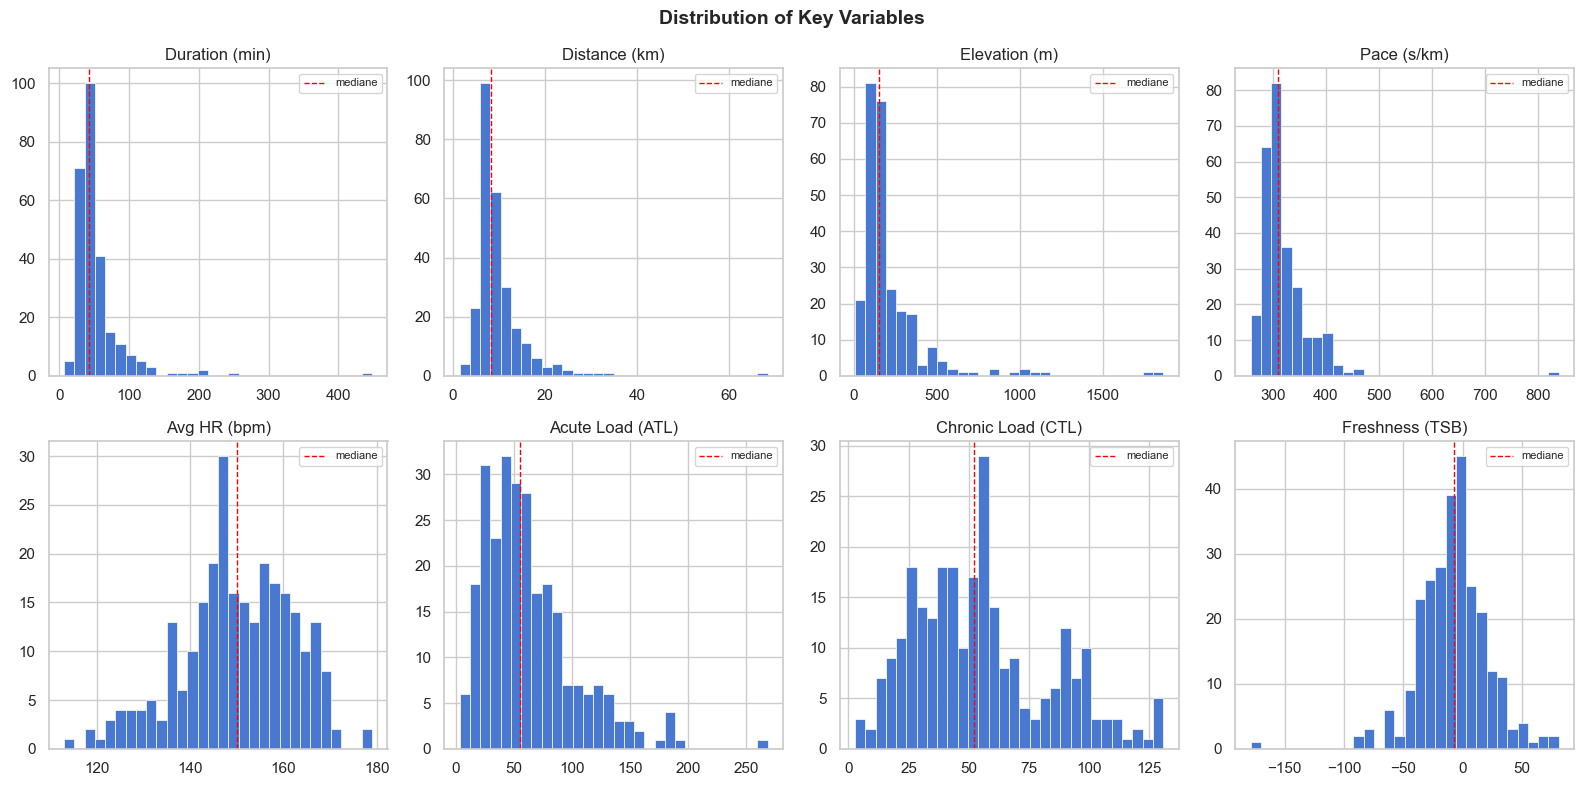

Chart saved


In [13]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Distribution of Key Variables", fontsize=14, fontweight="bold")

cols = [
    ("duration_min",       "Duration (min)"),
    ("distance_km",     "Distance (km)"),
    ("elevation_m",      "Elevation (m)"),
    ("pace_s_km",     "Pace (s/km)"),
    ("avg_hr",          "Avg HR (bpm)"),
    ("ATL",             "Acute Load (ATL)"),
    ("CTL",             "Chronic Load (CTL)"),
    ("TSB",             "Freshness (TSB)"),
]

for ax, (col, label) in zip(axes.flat, cols):
    data = df_run[col].dropna()
    ax.hist(data, bins=30, edgecolor="white", linewidth=0.5)
    ax.set_title(label)
    ax.set_xlabel("")
    ax.axvline(data.median(), color="red", linestyle="--", linewidth=1, label="mediane")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "eda_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved")

#### 2 Temporal Evolution

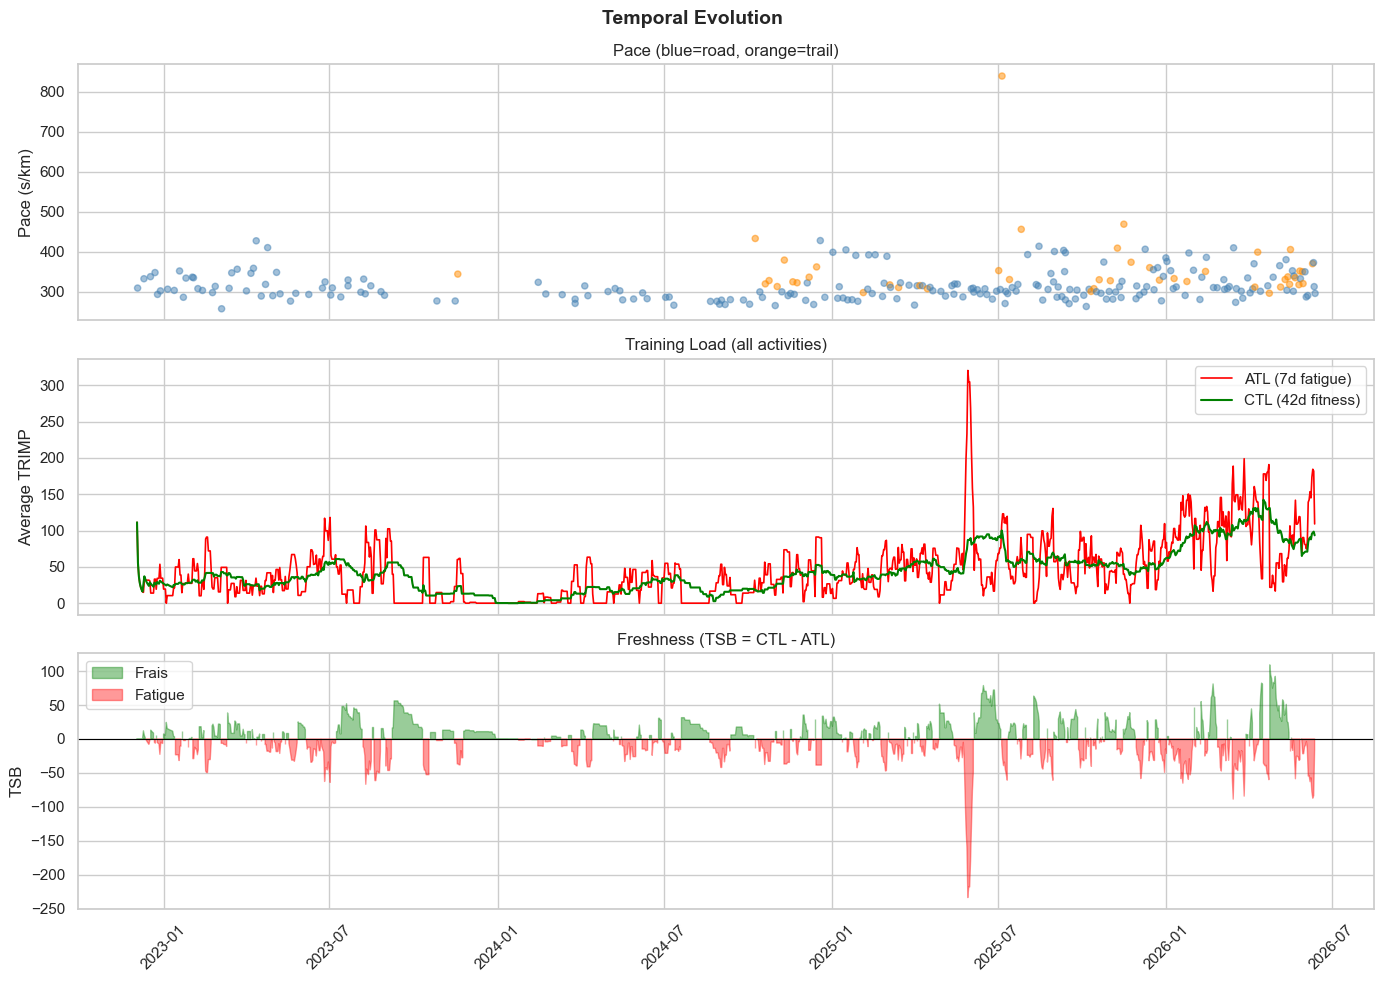

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Temporal Evolution", fontsize=14, fontweight="bold")

# Pace over time
axes[0].scatter(df_run["date"], df_run["pace_s_km"], alpha=0.5, s=20,
                c=df_run["is_trail"].map({0: "steelblue", 1: "darkorange"}))
axes[0].set_ylabel("Pace (s/km)")
axes[0].set_title("Pace (blue=road, orange=trail)")

# Charge ATL/CTL
axes[1].plot(atl.index, atl.values, label="ATL (7d fatigue)",  color="red",   linewidth=1.2)
axes[1].plot(ctl.index, ctl.values, label="CTL (42d fitness)",   color="green", linewidth=1.5)
axes[1].set_ylabel("Average TRIMP")
axes[1].set_title("Training Load (all activities)")
axes[1].legend()

# TSB
axes[2].fill_between(tsb.index, tsb.values, 0,
                     where=(tsb.values >= 0), alpha=0.4, color="green", label="Frais")
axes[2].fill_between(tsb.index, tsb.values, 0,
                     where=(tsb.values < 0),  alpha=0.4, color="red",   label="Fatigue")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_ylabel("TSB")
axes[2].set_title("Freshness (TSB = CTL - ATL)")
axes[2].legend()

axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "eda_temporal.png", dpi=150, bbox_inches="tight")
plt.show()

#### 3 Corrélations avec la variable cible (duration_s)

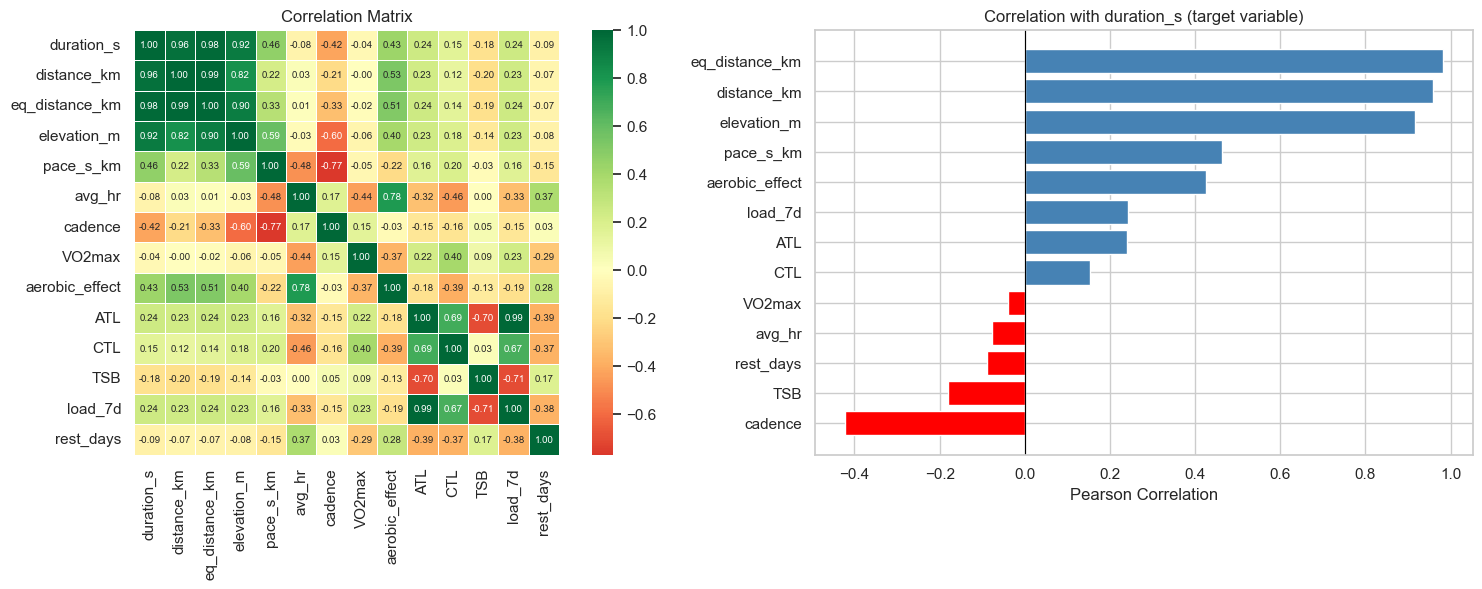


Correlations with duration_s:
eq_distance_km    0.981481
distance_km       0.957645
elevation_m       0.915992
pace_s_km         0.463075
aerobic_effect    0.425573
load_7d           0.242088
ATL               0.239285
CTL               0.153691
VO2max           -0.039701
avg_hr           -0.077124
rest_days        -0.088719
TSB              -0.179657
cadence          -0.422566


In [15]:
NUMERIC_FEATURES = [
    "duration_s", "distance_km", "eq_distance_km", "elevation_m",
    "pace_s_km", "avg_hr", "cadence", "VO2max",
    "aerobic_effect", "ATL", "CTL", "TSB", "load_7d", "rest_days",
]

corr = df_run[NUMERIC_FEATURES].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, square=True, linewidths=0.5,
    ax=axes[0], annot_kws={"size": 7}
)
axes[0].set_title("Correlation Matrix")

# Correlation avec duration_s uniquement
corr_target = corr["duration_s"].drop("duration_s").sort_values()
colors = ["red" if v < 0 else "steelblue" for v in corr_target]
axes[1].barh(corr_target.index, corr_target.values, color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlation with duration_s (target variable)")
axes[1].set_xlabel("Pearson Correlation")

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "eda_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nCorrelations with duration_s:")
print(corr_target.sort_values(ascending=False).to_string())

#### 4 Scatter Plots — Most Correlated Variables

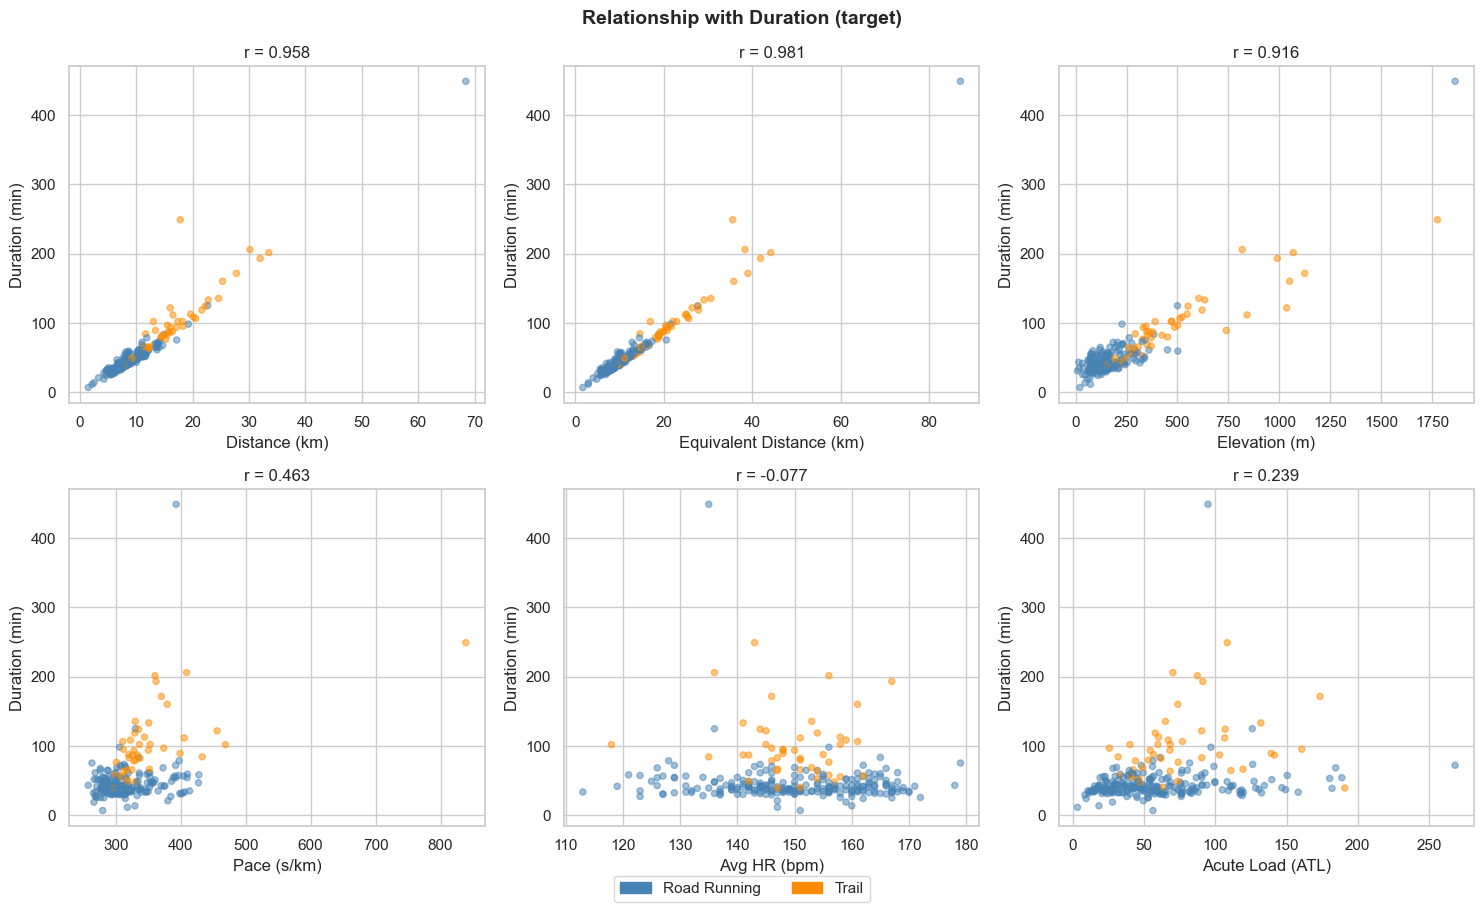

In [16]:
top_features = [
    ("distance_km",    "Distance (km)"),
    ("eq_distance_km", "Equivalent Distance (km)"),
    ("elevation_m",     "Elevation (m)"),
    ("pace_s_km",    "Pace (s/km)"),
    ("avg_hr",         "Avg HR (bpm)"),
    ("ATL",            "Acute Load (ATL)"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Relationship with Duration (target)", fontsize=14, fontweight="bold")

colors = df_run["is_trail"].map({0: "steelblue", 1: "darkorange"})

for ax, (col, label) in zip(axes.flat, top_features):
    ax.scatter(df_run[col], df_run["duration_s"] / 60, alpha=0.5, s=20, c=colors)
    ax.set_xlabel(label)
    ax.set_ylabel("Duration (min)")
    r = df_run[[col, "duration_s"]].dropna().corr().iloc[0, 1]
    ax.set_title("r = {:.3f}".format(r))

# Manual legend
from matplotlib.patches import Patch
legend = [
    Patch(color="steelblue",   label="Road Running"),
    Patch(color="darkorange",  label="Trail"),
]
fig.legend(handles=legend, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "eda_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

#### 5 Statistical Summary of the Final Dataset

In [17]:
print("=" * 60)
print("MODELLING DATASET SUMMARY")
print("=" * 60)
print("Total runs       : {}".format(len(df_run)))
print("  of which road  : {}".format((df_run["type"] == "running").sum()))
print("  of which trail : {}".format((df_run["type"] == "trail_running").sum()))
print("Periode            : {} -> {}".format(
    df_run["date"].min().date(), df_run["date"].max().date()))
print()
print("Distance         : {:.1f} - {:.1f} km (avg {:.1f})".format(
    df_run["distance_km"].min(), df_run["distance_km"].max(), df_run["distance_km"].mean()))
print("Duration         : {:.0f} - {:.0f} min (avg {:.0f})".format(
    df_run["duration_min"].min(), df_run["duration_min"].max(), df_run["duration_min"].mean()))
print("Elevation        : {:.0f} - {:.0f} m (avg {:.0f})".format(
    df_run["elevation_m"].min(), df_run["elevation_m"].max(), df_run["elevation_m"].mean()))
print("Pace             : {:.0f} - {:.0f} s/km (avg {:.0f})".format(
    df_run["pace_s_km"].min(), df_run["pace_s_km"].max(), df_run["pace_s_km"].mean()))
print()
print("Available features:")
for col in FEATURES:
    if col not in ["id", "date", "type", "name"]:
        pct_null = df_run[col].isnull().mean() * 100
        print("  {:25s} missing: {:.1f}%".format(col, pct_null))

print("\nReady for Phase 2: Modelling")

MODELLING DATASET SUMMARY
Total runs       : 265
  of which road  : 220
  of which trail : 45
Periode            : 2022-12-03 -> 2026-06-12

Distance         : 1.5 - 68.5 km (avg 9.9)
Duration         : 7 - 448 min (avg 54)
Elevation        : 9 - 1864 m (avg 216)
Pace             : 258 - 839 s/km (avg 321)

Available features:
  duration_s                missing: 0.0%
  distance_km               missing: 0.0%
  eq_distance_km            missing: 0.0%
  elevation_m               missing: 0.0%
  elevation_per_km          missing: 0.0%
  pace_s_km                 missing: 0.0%
  eq_pace_s_km              missing: 0.0%
  avg_hr                    missing: 0.0%
  max_hr                    missing: 0.0%
  cadence                   missing: 0.0%
  VO2max                    missing: 0.0%
  aerobic_effect            missing: 0.0%
  anaerobic_effect          missing: 0.0%
  calories                  missing: 0.0%
  is_trail                  missing: 0.0%
  month                     missing: 0.0%

## Phase 2 — Modelling

**Goal** : predict `duration_s` (total time in seconds) and after that deduct the pace in min/km

**Validation strategy**: temporal split
- Training: the oldest 80% run
- Test: the latest 20% run

**Models compared**:
1. Linear Regression (baseline)
2. Random Forest
3. XGBoost

**Metrics**: MAE (mean absolute error), RMSE, R²

### 2.1 Imports and Loading

In [18]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.linear_model  import Ridge
from sklearn.ensemble      import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline      import Pipeline
from sklearn.metrics       import mean_absolute_error, mean_squared_error, r2_score

# XGBoost desactive (incompatibilite Python 3.9 / macOS)
HAS_XGB = False
print("XGBoost desactive — modeles utilises : Ridge + Random Forest")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

PROCESSED_DIR = Path("data/processed")
MODELS_DIR    = Path("data/models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED_DIR / "running_dataset.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Dataset loaded: {} runs".format(len(df)))
print("Periode : {} -> {}".format(df["date"].min().date(), df["date"].max().date()))

XGBoost desactive — modeles utilises : Ridge + Random Forest
Dataset loaded: 265 runs
Periode : 2022-12-03 -> 2026-06-12


### 2.2 Feature Definition and Temporal Split

In [19]:
# Input features for predicting a FUTURE RACE
# Note: avg_power, norm_power, stride_length, fastest_splits, pct_zones
#        are POST-race features -> NOT used for prediction
#        On garde : training_load (Garmin load), grade_adj_pace (si connue)
FEATURES_INPUT = [
    # Planned race parameters
    "distance_km",
    "eq_distance_km",
    "elevation_m",
    "elevation_per_km",
    "is_trail",
    "month",
    # Race fatigue features
    "riegel_factor",
    "difficulty_index",
    "log_eq_distance",
    "relative_elevation",
    # Fitness state
    "ATL",
    "CTL",
    "TSB",
    "load_7d",
    "load_28d",
    "rest_days",
    # Physical capacity
    "VO2max",
    # Garmin load (available before race = cumulative previous sessions)
    "training_load",
]

TARGET = "duration_s"

# Split temporel dynamique 80/20 (80% oldest runs for traintrainement, 20% les plus recentes pour le test)
SPLIT_IDX = int(len(df) * 0.80)
train = df.iloc[:SPLIT_IDX].copy()
test  = df.iloc[SPLIT_IDX:].copy()

X_train = train[FEATURES_INPUT]
y_train = train[TARGET]
X_test  = test[FEATURES_INPUT]
y_test  = test[TARGET]

print("Split dynamique 80/20 (date de coupure : {})".format(
    train["date"].max().date()))
print("Train: {} runs ({} -> {})".format(
    len(train), train["date"].min().date(), train["date"].max().date()))
print("Test : {} runs ({} -> {})".format(
    len(test),  test["date"].min().date(),  test["date"].max().date()))
print("\nFeatures ({}) : {}".format(len(FEATURES_INPUT), FEATURES_INPUT))

Split dynamique 80/20 (date de coupure : 2026-01-11)
Train: 212 runs (2022-12-03 -> 2026-01-11)
Test : 53 runs (2026-01-21 -> 2026-06-12)

Features (18) : ['distance_km', 'eq_distance_km', 'elevation_m', 'elevation_per_km', 'is_trail', 'month', 'riegel_factor', 'difficulty_index', 'log_eq_distance', 'relative_elevation', 'ATL', 'CTL', 'TSB', 'load_7d', 'load_28d', 'rest_days', 'VO2max', 'training_load']


### 2.3 Evaluation Function

In [20]:
def fmt_time(seconds):
    """Convert seconds to h:mm:ss string."""
    seconds = int(abs(seconds))
    h  = seconds // 3600
    m  = (seconds % 3600) // 60
    s  = seconds % 60
    return "{:d}:{:02d}:{:02d}".format(h, m, s)


def evaluate(name, y_true, y_pred):
    """Compute and display metrics for a model."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    # Erreur en pace : MAE / distance moyenne du test
    dist_moy = test["distance_km"].mean()
    mae_pace = mae / dist_moy / 60  # min/km

    print("{:20s}  MAE={:>8s}  RMSE={:>8s}  R2={:.3f}  Erreur pace~{:+.1f}s/km".format(
        name, fmt_time(mae), fmt_time(rmse), r2, mae / dist_moy
    ))
    return {"name": name, "MAE_s": mae, "RMSE_s": rmse, "R2": r2,
            "MAE_min_km": mae_pace}


results = []
print("Evaluation functions defined")

Evaluation functions defined


### 2.4 Model 1 — Ridge Regression (baseline)

In [21]:
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  Ridge(alpha=1.0)),
])

pipe_lr.fit(X_train, y_train)
pred_lr = pipe_lr.predict(X_test)

res = evaluate("Ridge", y_test, pred_lr)
results.append(res)

# Coefficients
coefs = pd.Series(
    pipe_lr.named_steps["model"].coef_,
    index=FEATURES_INPUT
).sort_values(key=abs, ascending=False)
print("\nCoefficients (standardized):")
print(coefs.to_string())

Ridge                 MAE= 0:06:55  RMSE= 0:08:24  R2=0.922  Erreur pace~+38.1s/km

Coefficients (standardized):
elevation_m           1213.634999
eq_distance_km         550.469656
difficulty_index       541.649884
training_load         -346.488345
load_7d                289.965820
distance_km            274.837842
riegel_factor          212.975809
elevation_per_km      -194.473256
relative_elevation    -194.473256
log_eq_distance        172.729597
TSB                    169.389998
VO2max                -149.598310
load_28d              -134.403932
ATL                   -103.998815
is_trail               -77.711775
CTL                     62.279706
month                    5.952652
rest_days                2.733976


### 2.5 Model 2 — Random Forest

In [22]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

res = evaluate("Random Forest", y_test, pred_rf)
results.append(res)

# Feature importance
fi_rf = pd.Series(rf.feature_importances_, index=FEATURES_INPUT).sort_values(ascending=False)
print("\nFeature importance (RF):")
print(fi_rf.to_string())

Random Forest         MAE= 0:05:14  RMSE= 0:10:06  R2=0.887  Erreur pace~+28.9s/km

Feature importance (RF):
difficulty_index      0.256522
log_eq_distance       0.240751
eq_distance_km        0.217510
elevation_m           0.138368
distance_km           0.071499
riegel_factor         0.051988
training_load         0.010604
TSB                   0.003406
elevation_per_km      0.001822
ATL                   0.001659
VO2max                0.001547
load_7d               0.001100
relative_elevation    0.001002
CTL                   0.000789
load_28d              0.000663
rest_days             0.000392
month                 0.000277
is_trail              0.000101


### 2.6 Model 3 — XGBoost

In [23]:
try:
    import importlib
    import xgboost
    importlib.reload(xgboost)
    from xgboost import XGBRegressor
    HAS_XGB = True
    print("XGBoost version : {}".format(xgboost.__version__))
except Exception as e:
    print("XGBoost unavailable: {}".format(e))
    HAS_XGB = False

if HAS_XGB:
    xgb = XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0,
    )
    xgb.fit(X_train, y_train)
    pred_xgb = xgb.predict(X_test)

    res = evaluate("XGBoost", y_test, pred_xgb)
    results.append(res)

    fi_xgb = pd.Series(
        xgb.feature_importances_, index=FEATURES_INPUT
    ).sort_values(ascending=False)
    print("\nFeature importance (XGB):")
    print(fi_xgb.to_string())
else:
    print("XGBoost saute — relancer apres : pip install xgboost==1.7.6")

XGBoost version : 1.7.6
XGBoost               MAE= 0:04:05  RMSE= 0:06:38  R2=0.951  Erreur pace~+22.6s/km

Feature importance (XGB):
difficulty_index      0.406903
eq_distance_km        0.288702
elevation_m           0.164895
distance_km           0.050179
log_eq_distance       0.049361
riegel_factor         0.027469
is_trail              0.002879
CTL                   0.002618
training_load         0.002147
ATL                   0.000764
VO2max                0.000751
month                 0.000728
relative_elevation    0.000577
load_28d              0.000506
rest_days             0.000395
load_7d               0.000388
TSB                   0.000375
elevation_per_km      0.000362


### 2.7 Model Comparison

MODEL COMPARISON (on test set)
         name MAE_fmt RMSE_fmt       R2  MAE_min_km
        Ridge 0:06:55  0:08:24 0.921678    0.634649
Random Forest 0:05:14  0:10:06 0.886783    0.480924
      XGBoost 0:04:05  0:06:38 0.951141    0.375925

Best model: XGBoost (MAE = 0:04:05)


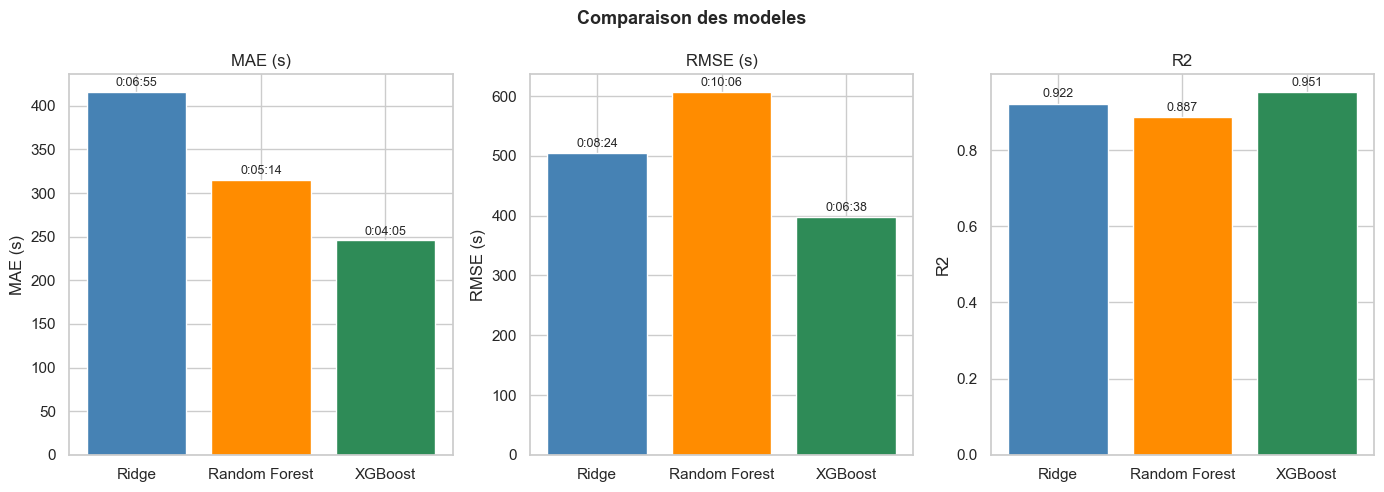

In [24]:
df_results = pd.DataFrame(results)
df_results["MAE_fmt"]  = df_results["MAE_s"].apply(fmt_time)
df_results["RMSE_fmt"] = df_results["RMSE_s"].apply(fmt_time)

print("=" * 65)
print("MODEL COMPARISON (on test set)")
print("=" * 65)
print(df_results[["name", "MAE_fmt", "RMSE_fmt", "R2", "MAE_min_km"]].to_string(index=False))

# Best model
best_idx  = df_results["MAE_s"].idxmin()
best_name = df_results.loc[best_idx, "name"]
print("\nBest model: {} (MAE = {})".format(
    best_name, df_results.loc[best_idx, "MAE_fmt"]))

# Comparison chart
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Comparaison des modeles", fontsize=13, fontweight="bold")

metrics = [("MAE_s", "MAE (s)"), ("RMSE_s", "RMSE (s)"), ("R2", "R2")]
for ax, (col, label) in zip(axes, metrics):
    vals  = df_results[col]
    names  = df_results["name"]
    bars  = ax.bar(names, vals, color=["steelblue", "darkorange", "seagreen"][:len(vals)])
    ax.set_title(label)
    ax.set_ylabel(label)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                "{:.3f}".format(val) if col == "R2" else fmt_time(val),
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.8 Residual Analysis — Best Model

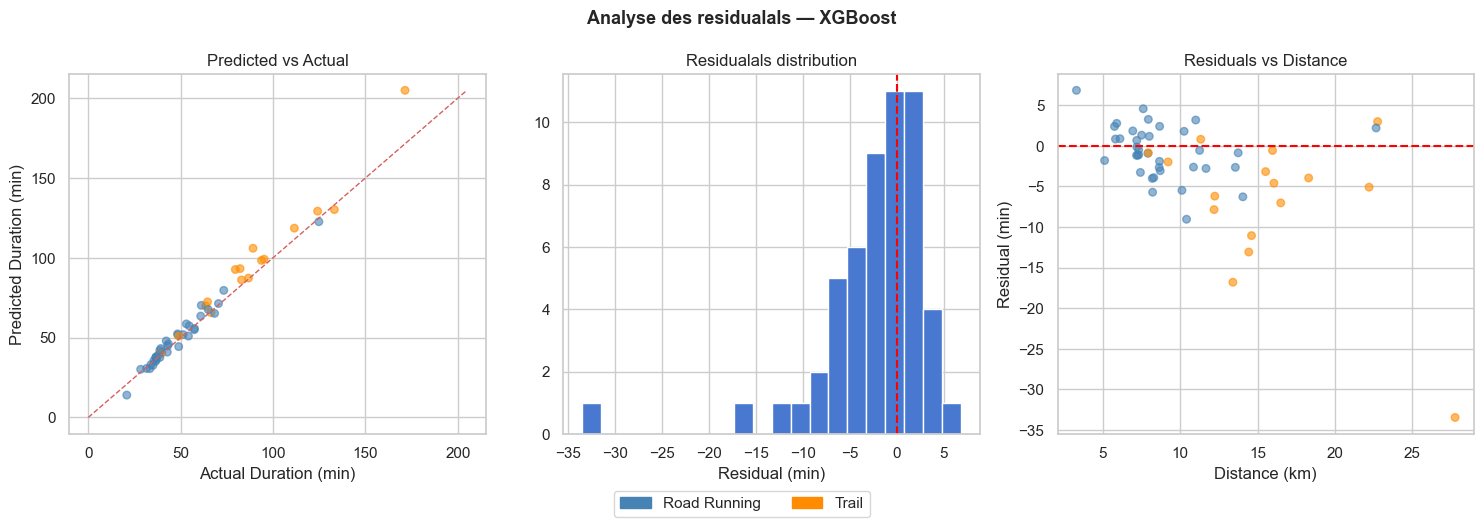

Mean bias: -156s (-2.6 min)
Standard deviation residualals : 366s (6.1 min)


In [25]:
# Select best model predictions
preds_map = {"Ridge": pred_lr, "Random Forest": pred_rf}
if HAS_XGB:
    preds_map["XGBoost"] = pred_xgb

best_pred = preds_map[best_name]
residualals   = y_test.values - best_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Analyse des residualals — {}".format(best_name), fontsize=13, fontweight="bold")

# Predicted vs actual
lim = max(y_test.max(), best_pred.max()) / 60
axes[0].scatter(y_test / 60, best_pred / 60, alpha=0.6, s=30,
                c=test["is_trail"].map({0: "steelblue", 1: "darkorange"}))
axes[0].plot([0, lim], [0, lim], "r--", linewidth=1)
axes[0].set_xlabel("Actual Duration (min)")
axes[0].set_ylabel("Predicted Duration (min)")
axes[0].set_title("Predicted vs Actual")

# Distribution des residualals
axes[1].hist(residualals / 60, bins=20, edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual (min)")
axes[1].set_title("Residualals distribution")

# Residuals vs distance
axes[2].scatter(test["distance_km"], residualals / 60, alpha=0.6, s=30,
                c=test["is_trail"].map({0: "steelblue", 1: "darkorange"}))
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set_xlabel("Distance (km)")
axes[2].set_ylabel("Residual (min)")
axes[2].set_title("Residuals vs Distance")

legend = [
    mpatches.Patch(color="steelblue",  label="Road Running"),
    mpatches.Patch(color="darkorange", label="Trail"),
]
fig.legend(handles=legend, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "model_residualals.png", dpi=150, bbox_inches="tight")
plt.show()

print("Mean bias: {:.0f}s ({:+.1f} min)".format(residualals.mean(), residualals.mean() / 60))
print("Standard deviation residualals : {:.0f}s ({:.1f} min)".format(residualals.std(), residualals.std() / 60))

### 2.9 Feature Importance — Chart

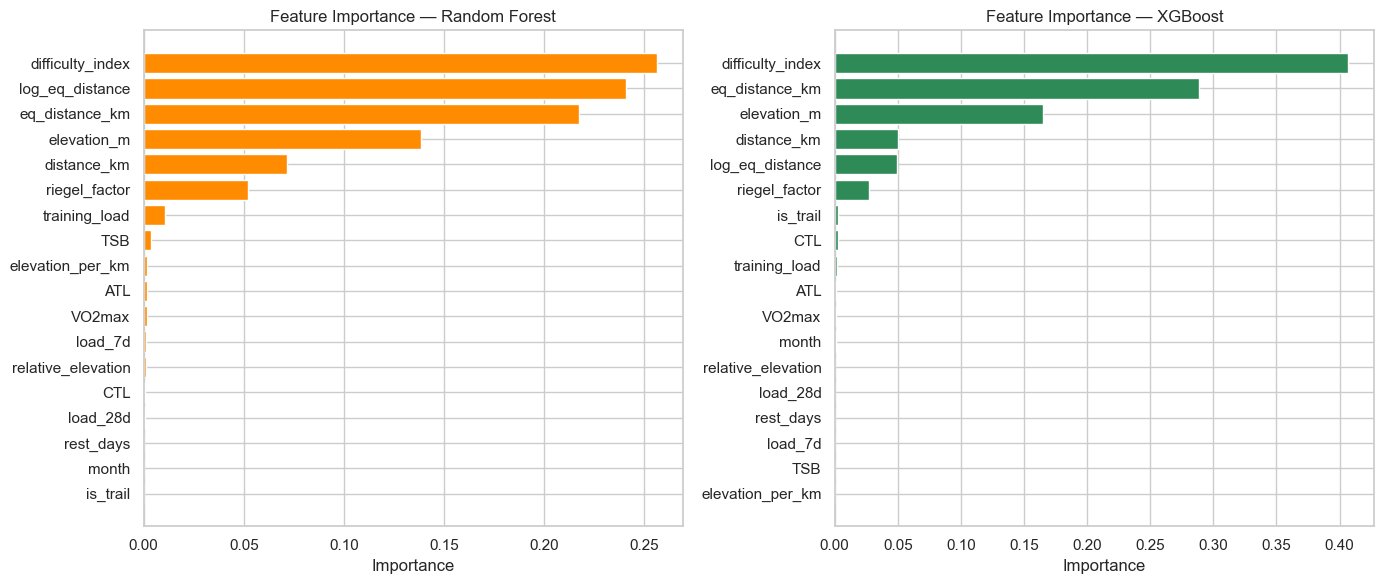

In [26]:
fig, axes = plt.subplots(1, 2 if HAS_XGB else 1,
                         figsize=(14 if HAS_XGB else 7, 6))

if not HAS_XGB:
    axes = [axes]

# Random Forest
fi_rf_sorted = fi_rf.sort_values()
axes[0].barh(fi_rf_sorted.index, fi_rf_sorted.values, color="darkorange")
axes[0].set_title("Feature Importance — Random Forest")
axes[0].set_xlabel("Importance")

# XGBoost
if HAS_XGB:
    fi_xgb_sorted = fi_xgb.sort_values()
    axes[1].barh(fi_xgb_sorted.index, fi_xgb_sorted.values, color="seagreen")
    axes[1].set_title("Feature Importance — XGBoost")
    axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.10 Saving the Final Model

In [27]:
models_map = {"Ridge": pipe_lr, "Random Forest": rf}
if HAS_XGB:
    models_map["XGBoost"] = xgb

best_model = models_map[best_name]

# Save
model_path    = MODELS_DIR / "best_model.pkl"
features_path = MODELS_DIR / "features.json"

joblib.dump(best_model, model_path)

import json
with open(features_path, "w") as f:
    json.dump({"features": FEATURES_INPUT, "model": best_name,
               "target": TARGET}, f, indent=2)

print("Model saved: {}".format(model_path))
print("Features saved: {}".format(features_path))

# Verification: test prediction on an example race
exemple = X_test.iloc[0].to_dict()
pred_s  = float(best_model.predict(pd.DataFrame([exemple]))[0])
reel_s  = float(y_test.iloc[0])
dist_km = float(test["distance_km"].iloc[0])

print("\n--- Prediction example ---")
print("Distance    : {:.1f} km".format(dist_km))
print("Actual time : {} ({}s)".format(fmt_time(reel_s), int(reel_s)))
print("Predicted   : {} ({}s)".format(fmt_time(pred_s), int(pred_s)))
print("Actual pace : {:.2f} min/km".format(reel_s / dist_km / 60))
print("Pred. pace  : {:.2f} min/km".format(pred_s / dist_km / 60))
print("Gap         : {:+.0f}s ({:+.1f} min)".format(
    pred_s - reel_s, (pred_s - reel_s) / 60))

Model saved: data/models/best_model.pkl
Features saved: data/models/features.json

--- Prediction example ---
Distance    : 7.5 km
Actual time : 0:36:24 (2184s)
Predicted   : 0:35:05 (2105s)
Actual pace : 4.85 min/km
Pred. pace  : 4.68 min/km
Gap         : -79s (-1.3 min)


### Pre-app Tests

In [28]:
import joblib, json
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import date

model_sim = joblib.load(Path("data/models/best_model.pkl"))
with open(Path("data/models/features.json")) as f:
    meta_sim = json.load(f)

df_sim = pd.read_csv(Path("data/processed/all_activities_clean.csv"), parse_dates=["date"])
df_sim = df_sim.sort_values("date").reset_index(drop=True)

# Also load running dataset for training_load median
df_run_sim = pd.read_csv(Path("data/processed/running_dataset.csv"), parse_dates=["date"])
training_load_med = df_run_sim["training_load"].median()

FC_REPOS_SIM = 45
FC_MAX_SIM   = 185
RIEGEL_B     = 1.06
DIST_MAX_ML  = 68.5
DENI_MAX_ML  = 1864

def compute_trimp_sim(duration_min, avg_hr):
    if pd.isna(avg_hr) or duration_min <= 0:
        return 0.0
    hr_norm = max(0, min((avg_hr - FC_REPOS_SIM) / max(FC_MAX_SIM - FC_REPOS_SIM, 1), 1))
    return duration_min * hr_norm * 0.64 * np.exp(1.92 * hr_norm)

if "trimp" not in df_sim.columns:
    df_sim["trimp"] = df_sim.apply(
        lambda r: compute_trimp_sim(r["duration_min"], r["avg_hr"]), axis=1)

trimp_daily_sim = df_sim[["date", "trimp"]].set_index("date")["trimp"].resample("D").sum()
atl_sim      = trimp_daily_sim.rolling(7,  min_periods=1).mean()
ctl_sim      = trimp_daily_sim.rolling(42, min_periods=1).mean()
tsb_sim      = ctl_sim - atl_sim
load_7d_sim  = trimp_daily_sim.rolling(7,  min_periods=1).sum()
load_28d_sim = trimp_daily_sim.rolling(28, min_periods=1).sum()

def get_charge_sim(target_date, series):
    ts   = pd.Timestamp(target_date)
    prev = series[series.index < ts]
    return float(prev.iloc[-1]) if len(prev) > 0 else 0.0

def get_repos_sim(target_date):
    ts   = pd.Timestamp(target_date)
    prev = df_sim[df_sim["date"] < ts]
    return 0 if len(prev) == 0 else max(0, (ts - prev["date"].max()).days)

def get_training_load(target_date):
    """Garmin load from the last run before the target date."""
    ts   = pd.Timestamp(target_date)
    prev = df_run_sim[df_run_sim["date"] < ts]
    if len(prev) == 0:
        return float(training_load_med)
    return float(prev["training_load"].iloc[-1])

vo2max_last = float(df_run_sim["VO2max"].dropna().iloc[-1])


def build_features(distance_km, elevation_m, is_trail, d):
    deq = distance_km + elevation_m / 100
    return {
        "distance_km"      : distance_km,
        "eq_distance_km"   : deq,
        "elevation_m"       : float(elevation_m),
        "elevation_per_km"  : elevation_m / distance_km,
        "is_trail"         : float(is_trail),
        "month"             : float(d.month),
        "riegel_factor"    : distance_km ** RIEGEL_B,
        "difficulty_index": deq ** RIEGEL_B,
        "log_eq_distance"  : np.log(deq),
        "relative_elevation" : elevation_m / distance_km,
        "ATL"              : get_charge_sim(d, atl_sim),
        "CTL"              : get_charge_sim(d, ctl_sim),
        "TSB"              : get_charge_sim(d, tsb_sim),
        "load_7d"          : get_charge_sim(d, load_7d_sim),
        "load_28d"         : get_charge_sim(d, load_28d_sim),
        "rest_days"      : float(get_repos_sim(d)),
        "VO2max"           : vo2max_last,
        "training_load"    : get_training_load(d),
    }


def predict_ml(distance_km, elevation_m, is_trail, d):
    features = build_features(distance_km, elevation_m, is_trail, d)
    X = pd.DataFrame([features])[meta_sim["features"]]
    return float(model_sim.predict(X)[0])


def predict_riegel(distance_km, elevation_m, is_trail, d):
    dist_ref  = DIST_MAX_ML
    deni_ref  = min(elevation_m, DENI_MAX_ML)
    deq_target = distance_km + elevation_m / 100
    deq_ref    = dist_ref + deni_ref / 100
    temps_ref  = predict_ml(dist_ref, deni_ref, is_trail, d)
    return temps_ref * (deq_target / deq_ref) ** RIEGEL_B


def predict_course(distance_km, elevation_m, is_trail=0, race_date="today"):
    if race_date == "today":
        race_date = str(date.today())
    d = pd.Timestamp(race_date)

    hors_distrib = (distance_km > DIST_MAX_ML) or (elevation_m > DENI_MAX_ML)

    if hors_distrib:
        pred_s  = predict_riegel(distance_km, elevation_m, is_trail, d)
        methode = "Riegel (extrapolation)"
    else:
        pred_s  = predict_ml(distance_km, elevation_m, is_trail, d)
        methode = "ML"

    pace = pred_s / distance_km
    h   = int(pred_s) // 3600
    m   = (int(pred_s) % 3600) // 60
    s   = int(pred_s) % 60
    am  = int(pace) // 60
    as_ = int(pace) % 60

    feat = build_features(distance_km, elevation_m, is_trail, d)
    print("Race       : {:.1f} km | D+ {}m | {} | {}".format(
        distance_km, elevation_m, "Trail" if is_trail else "Route", race_date))
    print("Methode    : {}".format(methode))
    print("Time       : {:d}:{:02d}:{:02d}".format(h, m, s))
    print("Avg pace   : {:d}:{:02d} /km".format(am, as_))
    print("ATL={:.1f}  CTL={:.1f}  TSB={:.1f}  Load={:.0f}".format(
        feat["ATL"], feat["CTL"], feat["TSB"], feat["training_load"]))
    print()
    return pred_s

# ── Simulations ──────────────────────────────────────────────────────────────
predict_course(distance_km=10,   elevation_m=100,   is_trail=0)
predict_course(distance_km=21,   elevation_m=300,   is_trail=0)
predict_course(distance_km=42,   elevation_m=500,   is_trail=0)
predict_course(distance_km=80,   elevation_m=4000,  is_trail=1)
predict_course(distance_km=170,  elevation_m=10000, is_trail=1)
predict_course(distance_km=34,   elevation_m=3000,   is_trail=1, race_date="2026-06-15")

Race       : 10.0 km | D+ 100m | Route | 2026-06-13
Methode    : ML
Time       : 0:49:12
Avg pace   : 4:55 /km
ATL=109.2  CTL=93.5  TSB=-15.7  Load=104

Race       : 21.0 km | D+ 300m | Route | 2026-06-13
Methode    : ML
Time       : 1:39:33
Avg pace   : 4:44 /km
ATL=109.2  CTL=93.5  TSB=-15.7  Load=104

Race       : 42.0 km | D+ 500m | Route | 2026-06-13
Methode    : ML
Time       : 3:17:09
Avg pace   : 4:41 /km
ATL=109.2  CTL=93.5  TSB=-15.7  Load=104

Race       : 80.0 km | D+ 4000m | Trail | 2026-06-13
Methode    : Riegel (extrapolation)
Time       : 10:33:43
Avg pace   : 7:55 /km
ATL=109.2  CTL=93.5  TSB=-15.7  Load=104

Race       : 170.0 km | D+ 10000m | Trail | 2026-06-13
Methode    : Riegel (extrapolation)
Time       : 24:56:57
Avg pace   : 8:48 /km
ATL=109.2  CTL=93.5  TSB=-15.7  Load=104

Race       : 34.0 km | D+ 3000m | Trail | 2026-06-15
Methode    : Riegel (extrapolation)
Time       : 5:25:08
Avg pace   : 9:33 /km
ATL=109.2  CTL=93.5  TSB=-15.7  Load=104



19508.467753586498